# Maze-ND substrate: generate data and display figures

TODO


artifact   : artifact:dungeongen/general/v1
schema     : raster-topology/v1
total rows : 500
inspect id : sha256:0042375d4acbb6739d10fbb993ef367da21f0d782b22c38d16b2cd44536bf838
projection_identity: sha256:ce862365743ae132fb28c44da51247915bf3711f4e759cba7d18bfbfe361d095


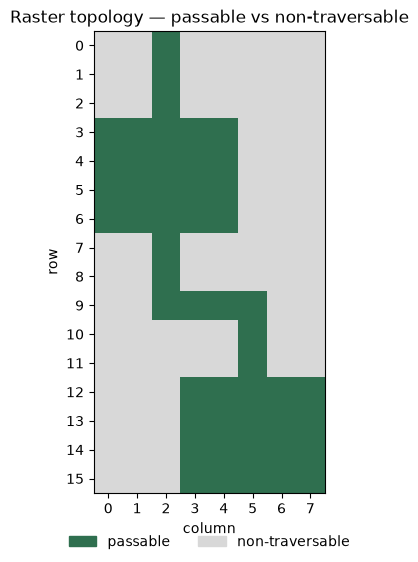

In [1]:
%matplotlib inline
from pathlib import Path

from ehp_sn.artifacts import load_release
from ehp_sn.figures import inspect_figure

# Resolve the committed artifact and choose a deterministic record.
# Record selection is deterministic: sort by canonical record_id, independent
# of build/enumeration order (projection.md "Deterministic selection").
artifact_dir = Path("data/interim/dungeongen/general/v1")
artifact = load_release(artifact_dir)

records = sorted(artifact.records, key=lambda r: r.record_id)
first = records[0]
print(f"artifact   : {artifact.artifact_ref}")
print(f"schema     : {first.schema_ref}")
print(f"total rows : {len(records)}")
print(f"inspect id : {first.record_id}")

# Record-scope inspection over that one authoritative record (public Python
# API — the same service the CLI `data inspect --figure` path calls).
result = inspect_figure(
    str(artifact_dir),
    first.record_id,
    "figure:raster-topology-inspection/v1",
)
print("projection_identity:", result.projection.identity())

artifact       : artifact:dungeongen/general/v1
schema         : raster-topology/v1
member records : 500
projection_identity: sha256:f8f2837286e40a07fd5b200663835d6748a74bb4218fe7192343aa120c489c28


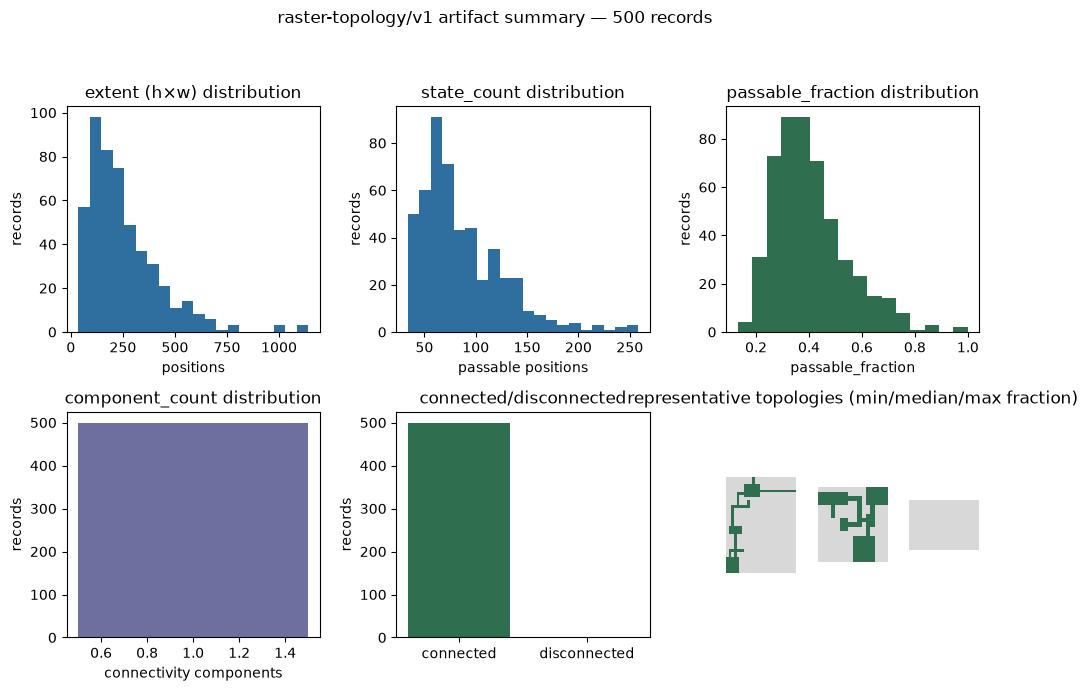

In [2]:
# Artifact-scope summary over the committed record collection. The collection
# schema is derived from the figure's own declared input requirement
# (service.py inspect_artifact_figure); Maze-ND conforms to raster-topology/v1.
from ehp_sn.figures import inspect_artifact_figure

summary = inspect_artifact_figure(
    str(artifact_dir),
    "figure:raster-topology-artifact-summary/v1",
)
proj = summary.projection
print(f"artifact       : {proj.source.artifact_ref}")
print(f"schema         : {proj.source.logical_contract}")
print(f"member records : {len(proj.source.record_ids or ())}")
print("projection_identity:", proj.identity())

artifact       : artifact:dungeongen/general/v1
schema         : raster-topology/v1
member records : 500
projection_identity: sha256:425cbf2d59971c4c0ae168f6e341739548238962beb1edd68c3eb252a9ff270a


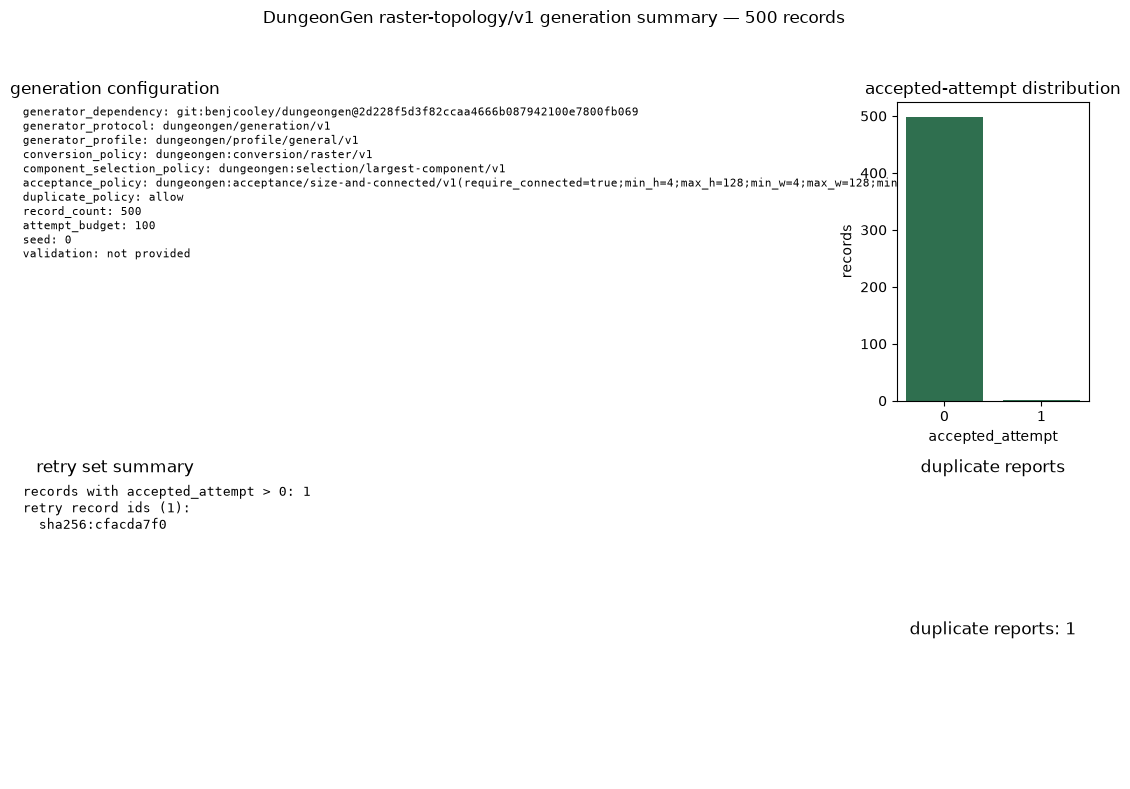

In [3]:
# Artifact-scope summary over the committed record collection. The collection
# schema is derived from the figure's own declared input requirement
# (service.py inspect_artifact_figure); Maze-ND conforms to raster-topology/v1.
from ehp_sn.figures import inspect_artifact_figure

summary = inspect_artifact_figure(
    str(artifact_dir),
    "figure:dungeongen-generation-summary/v1",
)
proj = summary.projection
print(f"artifact       : {proj.source.artifact_ref}")
print(f"schema         : {proj.source.logical_contract}")
print(f"member records : {len(proj.source.record_ids or ())}")
print("projection_identity:", proj.identity())